# Übung Simulation von Energiesystemen 
## PyPSA 03

#### Ihr Auftraggeber hat Ihnen den Auftrag erteilt, den von der Bundesregierung angestrebten Zubau von Gaskraftwerken zur Versorgungssicherheit zu prüfen. Sie sollen für das Jahr 2035 ein Zielszenario erstellen und dabei bestimmen, wie viel Gaskraftwerksleistung installiert werden müsste. Außerdem soll geprüft werden, ob der Strombedarf rein regenerativ mit elektrischen Speichern gedeckt werden könnte. Sie erhalten gemäß dem Netzentwicklungsplan für das Jahr 2035 eine Liste mit den verfügbaren Leistungen aus erneuerbaren Energien sowie die spezifischen Kosten für Gaskraftwerke und Energiespeicher.<br>
Ermitteln Sie nun die optimale Anlagen-, sowie Speichergrößen, die jährlichen Betriebs-, 
sowie die fälligen Investitionskosten und CO2-Emissionen <br> 
Im weiteren Verlauf ermitteln Sie die benötigte Gaskraftwerksleistung bei verschiedenen Speichergrößen.

Importieren Sie zunächst die notwendigen Bibliotheken

In [5]:
import pypsa
import pandas as pd

 Der Stromlastgang, sowie die Lastgänge für die fluktuierenden erneuerbaren Energien von Deutschland für das Jahr 2024 sind in der Datei "data_pypsa_03.csv" gespeichert. Lesen Sie diese mit pandas ein.

In [6]:
df_data = pd.read_csv('data_pypsa_03.csv')

In [7]:
df_data

,electrical_load,thermal_load,temperature
0,6.174443,30.557280,7.1
1,14.938390,28.706579,5.3
2,7.708502,32.409707,4.0
3,8.061687,33.336784,3.8
4,7.310149,27.781229,3.5
...,...,...,...
8755,7.693291,48.142390,10.5
8756,11.995080,27.929699,11.1
8757,5.372989,27.561976,11.6
8758,9.018624,39.411986,10.7


Erzeugen Sie aus den Daten Variablen, die bei den Kraftwerken den möglichen Leistungsbereich im Zeitverlauf einschränken. <br>
Hierzu ist Ihnen die installierte Kraftwerksleistung für das Jahr 2024 gegeben.

In [8]:
# Installierte Kraftwerksleistung im Jahr 2024 in Deutschland
pv_p_installed              = 76601 # MW
wind_onshore_p_installed    = 59841 # MW
wind_offshore_p_installed   = 8456  # MW
water_power_p_installed     = 5112  # MW

pv_p_max_pu             = df_data['Photovoltaik [MWh]']/pv_p_installed
wind_onshore_p_max_pu   = df_data['Wind onshore [MWh]']/wind_onshore_p_installed
wind_offshore_p_max_pu  = df_data['Wind offshore [MWh]']/wind_offshore_p_installed
water_power_p_max_pu    = df_data['Wasserkraft [MWh]']/water_power_p_installed
df_el_load              = df_data['Netzlast [MWh]']

C:\Users\sarah\anaconda3\Lib\site-packages\executing\executing.py:713: DeprecationWarning:

ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead

C:\Users\sarah\anaconda3\Lib\ast.py:587: DeprecationWarning:

Attribute s is deprecated and will be removed in Python 3.14; use value instead

C:\Users\sarah\anaconda3\Lib\site-packages\executing\executing.py:713: DeprecationWarning:

ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead

C:\Users\sarah\anaconda3\Lib\ast.py:587: DeprecationWarning:

Attribute s is deprecated and will be removed in Python 3.14; use value instead



KeyError: 'Photovoltaik [MWh]'

<Axes: >

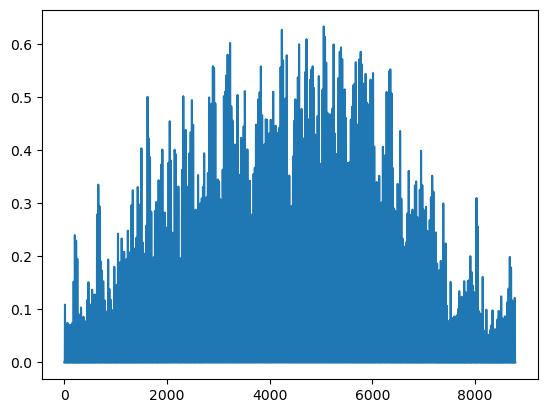

In [5]:
pv_p_max_pu.plot()

Folgende Angaben zur installierten Erzeugungsleistung zum Zieljahr 2035 erhalten Sie:

In [6]:
# Installierte Erzeugungsleistung zum Zieljahr 2035 (NEP Szenario C2035):
pv_p_nom            = 120100    # MW
wind_offshore_p_nom = 34000     # MW
wind_onshore_p_nom  = 90900     # MW
biomass_p_nom       = 8700      # MW
water_power_p_nom   = 5600      # MW

# Installierte Gaskraftwerksleistung heute:
gaspower_p_nom = 36200          # MW

Folgende Größen sind Ihnen zusätzlich gegeben:

In [7]:
co2_gaspower = 200                  # kg_CO2/MWh (Heizwert)
efficiency_gaspower = 0.4           # Wirkungsgrad Gaskraftwerk (Gasturbine)
marginal_cost_gaspower = 100        # €/MWh (Heizwert)
invest_gaspower =  2000000          # €/MW_el
lifetime_gaspower = 30              # Jahre

marginal_cost_biomass = 200         # €/MWh_el

capital_cost_el_storage = 400000    # €/MW (Großspeicher)
lifetime_storage = 15               # Jahre

Berechnen Sie die Annuität der Investitionskosten mit einem Zins von 3,5%.

In [8]:
def annuity(invest, t, r = 0.035):
    return invest * (r * (1 + r) ** t) / ((1 + r) ** t - 1)

# Berechnung der Annuität der Investitionskosten
annuity_gaspower = annuity(invest_gaspower, lifetime_gaspower)
annuity_storage = annuity(capital_cost_el_storage, lifetime_storage)

Implementieren Sie das System zunächst ohne Speicher um zu schauen wieviel Leistung an Gaskraftwerken installiert werden müsste:<br>

In [9]:
network = pypsa.Network()
network.set_snapshots(range(len(df_data)))

network.add('Carrier', 'Gas', co2_emissions = co2_gaspower)

network.add('Bus', name = 'electricity')

network.add('Load', name = 'el_load', bus = 'electricity', p_set = df_el_load)

network.add('Generator', name = 'pv', bus = 'electricity', p_max_pu = pv_p_max_pu, p_nom = pv_p_nom)
network.add('Generator', name = 'wind_offshore', bus = 'electricity', p_max_pu = wind_offshore_p_max_pu, p_nom = wind_offshore_p_nom)
network.add('Generator', name = 'wind_onshore', bus = 'electricity', p_max_pu = wind_onshore_p_max_pu, p_nom = wind_onshore_p_nom)
network.add('Generator', name = 'biomass', bus = 'electricity', p_nom = biomass_p_nom, marginal_cost = marginal_cost_biomass)
network.add('Generator', name = 'water_power', bus = 'electricity', p_max_pu = water_power_p_max_pu, p_nom = water_power_p_nom)

network.add('Generator', name = 'gas_power_ist', bus = 'electricity', p_nom = gaspower_p_nom, 
            marginal_cost = marginal_cost_gaspower/efficiency_gaspower,
            efficiency = efficiency_gaspower, carrier = 'Gas')

network.add('Generator', name = 'gas_power_add', bus = 'electricity', p_nom_extendable = True, 
            marginal_cost = marginal_cost_gaspower/efficiency_gaspower,
            efficiency = efficiency_gaspower,
            capital_cost = annuity_gaspower, carrier = 'Gas', 
            overwrite=True)


Index(['gas_power_add'], dtype='object')

Optimieren Sie das Netzwerk



In [10]:
network.optimize(solver_name = 'gurobi', threads = 1, method = 1)

Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - threads: 1
 - method: 1
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00,  7.25it/s]
INFO:linopy.io: Writing time: 1.01s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 5386 iterations and 0.49 seconds (0.29 work units)


INFO:gurobipy:Solved in 5386 iterations and 0.49 seconds (0.29 work units)


Optimal objective  3.041590444e+10


INFO:gurobipy:Optimal objective  3.041590444e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61489 primals, 131761 duals
Objective: 3.04e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

Anschließend geben Sie mit der folgenden Funktion die optimale Anlagengröße aus: <br>
network.generators.p_nom_opt <br>
Speicher Sie die Gaskraftwerksleistung in einer Liste.

In [11]:
network.generators.p_nom_opt

Generator
pv               120100.000000
wind_offshore     34000.000000
wind_onshore      90900.000000
biomass            8700.000000
water_power        5600.000000
gas_power_ist     36200.000000
gas_power_add     18509.364982
Name: p_nom_opt, dtype: float64

In [12]:
# Resuls in df speichern
df_results = pd.DataFrame(columns= ['Ohne Speicher', 'Optimal', 'Speicher * 1.25', 
                                    'Speicher * 1.5', 'Speicher * 1.75', 'Speicher * 2', 
                                    'Ohne add. Gaskraftwerke'], 
                          index = ['Investitionskosten [Mio. €]', 
                                   'Betriebskosten [Mio. €]',  
                                   'Installierte Gaskraftwerksleistung [MW]',
                                   'Installierte add. Gaskraftwerksleistung [MW]', 
                                   'Speicherkapazität in MWh',  
                                   'CO2-Emissionen in Mio. t CO2'])

df_results.loc['Installierte Gaskraftwerksleistung [MW]', 
               'Ohne Speicher'] = network.generators.p_nom_opt['gas_power_add'] + network.generators.p_nom_opt['gas_power_ist']
df_results.loc['Installierte add. Gaskraftwerksleistung [MW]', 
               'Ohne Speicher'] = network.generators.p_nom_opt['gas_power_add']
df_results

,Ohne Speicher,Optimal,Speicher * 1.25,Speicher * 1.5,Speicher * 1.75,Speicher * 2,Ohne add. Gaskraftwerke
Investitionskosten [Mio. €],NaN,NaN,NaN,NaN,NaN,NaN,NaN
Betriebskosten [Mio. €],NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installierte Gaskraftwerksleistung [MW],54709.364982,NaN,NaN,NaN,NaN,NaN,NaN
Installierte add. Gaskraftwerksleistung [MW],18509.364982,NaN,NaN,NaN,NaN,NaN,NaN
Speicherkapazität in MWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO2-Emissionen in Mio. t CO2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Schauen Sie sich mit "network.generators_t.p.plot()" an, wie die Erzeugungsleistung über das Jahr erfolgt

<Axes: xlabel='snapshot'>

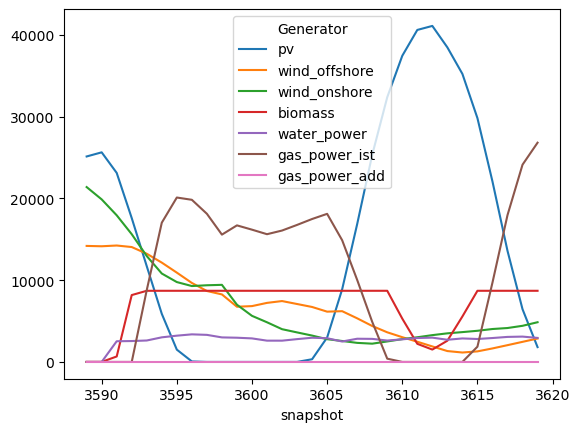

In [13]:
network.generators_t.p[3589:3620].plot()

Berechnen Sie nun die Investitions- und Betriebskosten des Systems: <br>
Speichern die diese Größen ebenfalls in Listen.

In [14]:
# V1, händisch berechnet
opex = (network.generators_t.p.sum() * network.generators.marginal_cost).sum() # €
invest = (network.generators.p_nom_opt * 
                   network.generators.capital_cost).sum()

print('Die Gesamtinvestitionskosten betragen: ', round(invest/1000000,2), 'mio €')
print('Die Betriebskosten betragen: ', round(opex/1000000,2), 'mio €')


Die Gesamtinvestitionskosten betragen:  2012.76 mio €
Die Betriebskosten betragen:  28403.15 mio €


In [15]:
# V2 mit statistics modul
opex = network.statistics.opex(groupby = 'name').sum()
invest = network.statistics.capex(groupby = 'name').sum()
opex, invest

(28403146798.2164, 2012757642.57122)

In [16]:
df_results.loc['Investitionskosten [Mio. €]', 'Ohne Speicher'] = round(invest/1000000,2)
df_results.loc['Betriebskosten [Mio. €]', 'Ohne Speicher'] = round(opex/1000000,2)
df_results

,Ohne Speicher,Optimal,Speicher * 1.25,Speicher * 1.5,Speicher * 1.75,Speicher * 2,Ohne add. Gaskraftwerke
Investitionskosten [Mio. €],2012.76,NaN,NaN,NaN,NaN,NaN,NaN
Betriebskosten [Mio. €],28403.15,NaN,NaN,NaN,NaN,NaN,NaN
Installierte Gaskraftwerksleistung [MW],54709.364982,NaN,NaN,NaN,NaN,NaN,NaN
Installierte add. Gaskraftwerksleistung [MW],18509.364982,NaN,NaN,NaN,NaN,NaN,NaN
Speicherkapazität in MWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO2-Emissionen in Mio. t CO2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Berechnung der CO2 Emissionen

Ermitteln Sie die anfallenden CO2 Emissionen im System. <br>
Speichern Sie auch diese Größe in einer Liste.

In [17]:
co2 = (network.generators_t.p[['gas_power_ist', 'gas_power_add']].sum().sum()/efficiency_gaspower) * network.carriers.co2_emissions['Gas']
co2 = co2/10**6/1000    # in Mio t CO2
print('Die CO2-Emissionen betragen: ', round(co2,2), 'Mio t CO2')
network.carriers.loc['Gas', 'co2_emissions']
network.carriers.co2_emissions

Die CO2-Emissionen betragen:  39.14 Mio t CO2


Carrier
Gas    200.0
Name: co2_emissions, dtype: float64

In [18]:
df_results.loc['CO2-Emissionen in Mio. t CO2', 'Ohne Speicher'] = round(co2,2)
df_results.loc['Speicherkapazität in MWh', 'Ohne Speicher'] = 0
df_results

,Ohne Speicher,Optimal,Speicher * 1.25,Speicher * 1.5,Speicher * 1.75,Speicher * 2,Ohne add. Gaskraftwerke
Investitionskosten [Mio. €],2012.76,NaN,NaN,NaN,NaN,NaN,NaN
Betriebskosten [Mio. €],28403.15,NaN,NaN,NaN,NaN,NaN,NaN
Installierte Gaskraftwerksleistung [MW],54709.364982,NaN,NaN,NaN,NaN,NaN,NaN
Installierte add. Gaskraftwerksleistung [MW],18509.364982,NaN,NaN,NaN,NaN,NaN,NaN
Speicherkapazität in MWh,0,NaN,NaN,NaN,NaN,NaN,NaN
CO2-Emissionen in Mio. t CO2,39.14,NaN,NaN,NaN,NaN,NaN,NaN


### Einfluss des Speichers auf das Energiesystem

Fügen Sie nun den elektrischen Speicher als 'StorageUnit' mit einer Kapazität für 2 Stunden hinzu. <br>

In [19]:
maxhours = 2
network.add('StorageUnit', name = 'el_storage', bus = 'electricity', max_hours = maxhours, 
           p_nom_extendable = True, capital_cost = annuity_storage, cyclic_state_of_charge = True,
           overwrite = True)

Index(['el_storage'], dtype='object')

Optimieren Sie das Sytsem mit dem Speicher.

In [20]:
network.optimize(solver_name='gurobi', method = 1, threads = 1)

Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - method: 1
 - threads: 1
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 32.35it/s]
INFO:linopy.io: Writing time: 1.55s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 29542 iterations and 2.70 seconds (2.15 work units)


INFO:gurobipy:Solved in 29542 iterations and 2.70 seconds (2.15 work units)


Optimal objective  2.687735075e+10


INFO:gurobipy:Optimal objective  2.687735075e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87842 primals, 193250 duals
Objective: 2.69e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

Geben Sie die optimierten installierten Kapazitäten der Gaskraftwerke und des elektrischen Speichers an: <br>
Speichern Sie diese Werte ebenfalls in der Liste ab.

In [21]:
network.storage_units.p_nom_opt

StorageUnit
el_storage    86005.692847
Name: p_nom_opt, dtype: float64

In [22]:
gaspower_size = network.generators.p_nom_opt['gas_power_add']
gaspower_size

5258.79819867027

In [23]:
storage_size = network.storage_units.p_nom_opt['el_storage'] * maxhours

In [24]:
print('Die zusätzliche Gaskraftwerksleistung beträgt ', round(gaspower_size,2), 'MW\nDie Speicherkapazität beträgt ', round(storage_size,2), 'MWh')

Die zusätzliche Gaskraftwerksleistung beträgt  5258.8 MW
Die Speicherkapazität beträgt  172011.39 MWh


In [25]:
# Werte in df_results eintragen
df_results.loc['Installierte Gaskraftwerksleistung [MW]', 'Optimal'] = round(network.generators.p_nom_opt['gas_power_add']
                                                                             + network.generators.p_nom_opt['gas_power_ist'],2)
df_results.loc['Installierte add. Gaskraftwerksleistung [MW]', 'Optimal'] = round(network.generators.p_nom_opt['gas_power_add'],2)
df_results.loc['Speicherkapazität in MWh', 'Optimal'] = round(network.storage_units.p_nom_opt['el_storage'] * maxhours,2)
df_results.loc['Speicherkapazität in MWh', 'Ohne Speicher'] = 0
df_results


,Ohne Speicher,Optimal,Speicher * 1.25,Speicher * 1.5,Speicher * 1.75,Speicher * 2,Ohne add. Gaskraftwerke
Investitionskosten [Mio. €],2012.76,NaN,NaN,NaN,NaN,NaN,NaN
Betriebskosten [Mio. €],28403.15,NaN,NaN,NaN,NaN,NaN,NaN
Installierte Gaskraftwerksleistung [MW],54709.364982,41458.8,NaN,NaN,NaN,NaN,NaN
Installierte add. Gaskraftwerksleistung [MW],18509.364982,5258.8,NaN,NaN,NaN,NaN,NaN
Speicherkapazität in MWh,0,172011.39,NaN,NaN,NaN,NaN,NaN
CO2-Emissionen in Mio. t CO2,39.14,NaN,NaN,NaN,NaN,NaN,NaN


Berechnen Sie auch hier die Investitions- und Betriebskosten sowie die CO2-Emissionen: <br>
Speichern Sie die Werte in den dafür vorgesehenen Listen ab.

In [26]:
opex = network.statistics.opex(groupby = 'name').sum()
invest = network.statistics.capex(groupby = 'name').sum()

In [27]:
co2 = (network.generators_t.p[['gas_power_ist', 'gas_power_add']].sum().sum()  
       * network.carriers.co2_emissions['Gas']/efficiency_gaspower)
co2 = co2/10**6/1000

In [28]:
df_results.loc['CO2-Emissionen in Mio. t CO2', 'Optimal'] = round(co2,2)
df_results.loc['Investitionskosten [Mio. €]', 'Optimal'] = round(invest/1000000,2)
df_results.loc['Betriebskosten [Mio. €]', 'Optimal'] = round(opex/1000000,2)
df_results

,Ohne Speicher,Optimal,Speicher * 1.25,Speicher * 1.5,Speicher * 1.75,Speicher * 2,Ohne add. Gaskraftwerke
Investitionskosten [Mio. €],2012.76,3558.84,NaN,NaN,NaN,NaN,NaN
Betriebskosten [Mio. €],28403.15,23318.51,NaN,NaN,NaN,NaN,NaN
Installierte Gaskraftwerksleistung [MW],54709.364982,41458.8,NaN,NaN,NaN,NaN,NaN
Installierte add. Gaskraftwerksleistung [MW],18509.364982,5258.8,NaN,NaN,NaN,NaN,NaN
Speicherkapazität in MWh,0,172011.39,NaN,NaN,NaN,NaN,NaN
CO2-Emissionen in Mio. t CO2,39.14,28.17,NaN,NaN,NaN,NaN,NaN


# Erhöhung der Speicherkapazität

Erhöhen Sie nun die Speichergröße um 25% und optimieren Sie das System anschließend erneut und vergleichen Sie die Anlangen- und Speichergrößen, sowie die Investitions- und Betriebskosten und die CO2 Emissionen mit den bereits ermittelten Ergebnissen.

In [29]:
p_nom_storage = network.storage_units.p_nom_opt['el_storage']

In [30]:
network.add('StorageUnit', name = 'el_storage', bus = 'electricity', max_hours = maxhours,  
            p_nom_extendable = False, p_nom = p_nom_storage * 1.25, 
            capital_cost = annuity_storage, cyclic_state_of_charge = True, overwrite = True)

Index(['el_storage'], dtype='object')

In [31]:
network.optimize(solver_name = 'gurobi', method = 1, threads = 1)

Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - method: 1
 - threads: 1
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 27.24it/s]
INFO:linopy.io: Writing time: 1.51s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 14890 iterations and 0.47 seconds (0.32 work units)


INFO:gurobipy:Solved in 14890 iterations and 0.47 seconds (0.32 work units)


Optimal objective  2.323747667e+10


INFO:gurobipy:Optimal objective  2.323747667e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87841 primals, 193249 duals
Objective: 2.32e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [32]:
co2 = (network.generators_t.p[['gas_power_ist', 'gas_power_add']].sum().sum()  
       * network.carriers.co2_emissions['Gas']/efficiency_gaspower)
co2 = co2/10**6/1000


In [33]:
df_results.loc['CO2-Emissionen in Mio. t CO2', 'Speicher * 1.25'] = round(co2,2)
df_results.loc['Investitionskosten [Mio. €]', 'Speicher * 1.25'] = round(network.statistics.capex(groupby = 'name').sum()/1000000,2)
df_results.loc['Betriebskosten [Mio. €]', 'Speicher * 1.25'] = round(network.statistics.opex(groupby = 'name').sum()/1000000,2)
df_results.loc['Installierte Gaskraftwerksleistung [MW]', 'Speicher * 1.25'] = round(network.generators.p_nom_opt['gas_power_add']
                                                                             + network.generators.p_nom_opt['gas_power_ist'],2)
df_results.loc['Installierte add. Gaskraftwerksleistung [MW]', 'Speicher * 1.25'] = round(network.generators.p_nom_opt['gas_power_add'],2)
df_results.loc['Speicherkapazität in MWh', 'Speicher * 1.25'] = round(network.storage_units.p_nom_opt['el_storage'] * maxhours,2)
df_results

,Ohne Speicher,Optimal,Speicher * 1.25,Speicher * 1.5,Speicher * 1.75,Speicher * 2,Ohne add. Gaskraftwerke
Investitionskosten [Mio. €],2012.76,3558.84,4191.27,NaN,NaN,NaN,NaN
Betriebskosten [Mio. €],28403.15,23318.51,22779.93,NaN,NaN,NaN,NaN
Installierte Gaskraftwerksleistung [MW],54709.364982,41458.8,40407.61,NaN,NaN,NaN,NaN
Installierte add. Gaskraftwerksleistung [MW],18509.364982,5258.8,4207.61,NaN,NaN,NaN,NaN
Speicherkapazität in MWh,0,172011.39,215014.23,NaN,NaN,NaN,NaN
CO2-Emissionen in Mio. t CO2,39.14,28.17,26.95,NaN,NaN,NaN,NaN


Erhöhen Sie nun die Speichergröße um 50% gegenüber des Ursprungswertes und führen die Schritte erneut durch.

In [34]:
network.add('StorageUnit', name = 'el_storage', bus = 'electricity', max_hours = maxhours,  p_nom_extendable = False, p_nom = p_nom_storage * 1.5, 
            capital_cost = annuity_storage, cyclic_state_of_charge = True, overwrite = True)

Index(['el_storage'], dtype='object')

In [35]:
network.optimize(solver_name = 'gurobi', method = 1, threads = 1)

Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - method: 1
 - threads: 1
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 27.58it/s]
INFO:linopy.io: Writing time: 1.22s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 14858 iterations and 0.71 seconds (0.32 work units)


INFO:gurobipy:Solved in 14858 iterations and 0.71 seconds (0.32 work units)


Optimal objective  2.269525576e+10


INFO:gurobipy:Optimal objective  2.269525576e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87841 primals, 193249 duals
Objective: 2.27e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [36]:
co2 = (network.generators_t.p[['gas_power_ist', 'gas_power_add']].sum().sum()  
       * network.carriers.co2_emissions['Gas']/efficiency_gaspower)
co2 = co2/10**6/1000

In [37]:
df_results.loc['CO2-Emissionen in Mio. t CO2', 'Speicher * 1.5'] = round(co2,2)
df_results.loc['Investitionskosten [Mio. €]', 'Speicher * 1.5'] = round(network.statistics.capex(groupby = 'name').sum()/1000000,2)
df_results.loc['Betriebskosten [Mio. €]', 'Speicher * 1.5'] = round(network.statistics.opex(groupby = 'name').sum()/1000000,2)
df_results.loc['Installierte Gaskraftwerksleistung [MW]', 'Speicher * 1.5'] = round(network.generators.p_nom_opt['gas_power_add']
                                                                             + network.generators.p_nom_opt['gas_power_ist'],2)
df_results.loc['Installierte add. Gaskraftwerksleistung [MW]', 'Speicher * 1.5'] = round(network.generators.p_nom_opt['gas_power_add'],2)
df_results.loc['Speicherkapazität in MWh', 'Speicher * 1.5'] = round(network.storage_units.p_nom_opt['el_storage'] * maxhours,2)
df_results

,Ohne Speicher,Optimal,Speicher * 1.25,Speicher * 1.5,Speicher * 1.75,Speicher * 2,Ohne add. Gaskraftwerke
Investitionskosten [Mio. €],2012.76,3558.84,4191.27,4849.79,NaN,NaN,NaN
Betriebskosten [Mio. €],28403.15,23318.51,22779.93,22325.94,NaN,NaN,NaN
Installierte Gaskraftwerksleistung [MW],54709.364982,41458.8,40407.61,39596.24,NaN,NaN,NaN
Installierte add. Gaskraftwerksleistung [MW],18509.364982,5258.8,4207.61,3396.24,NaN,NaN,NaN
Speicherkapazität in MWh,0,172011.39,215014.23,258017.08,NaN,NaN,NaN
CO2-Emissionen in Mio. t CO2,39.14,28.17,26.95,25.92,NaN,NaN,NaN


Erhöhen Sie nun die Speichergröße um 75% gegenüber des Ursprungswertes und führen die Schritte erneut durch.

In [38]:
network.add('StorageUnit', name = 'el_storage', bus = 'electricity', max_hours = maxhours,  p_nom_extendable = False, p_nom = p_nom_storage * 1.75, 
            capital_cost = annuity_storage, cyclic_state_of_charge = True, overwrite = True)

Index(['el_storage'], dtype='object')

In [39]:
network.optimize(solver_name = 'gurobi', method = 1, threads = 1)

Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - method: 1
 - threads: 1
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 27.40it/s]
INFO:linopy.io: Writing time: 1.54s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 14816 iterations and 0.43 seconds (0.32 work units)


INFO:gurobipy:Solved in 14816 iterations and 0.43 seconds (0.32 work units)


Optimal objective  2.221042816e+10


INFO:gurobipy:Optimal objective  2.221042816e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87841 primals, 193249 duals
Objective: 2.22e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [40]:
co2 = (network.generators_t.p[['gas_power_ist', 'gas_power_add']].sum().sum()  
       * network.carriers.co2_emissions['Gas']/efficiency_gaspower)
co2 = co2/10**6/1000

In [41]:
df_results.loc['CO2-Emissionen in Mio. t CO2', 'Speicher * 1.75'] = round(co2,2)
df_results.loc['Investitionskosten [Mio. €]', 'Speicher * 1.75'] = round(network.statistics.capex(groupby = 'name').sum()/1000000,2)
df_results.loc['Betriebskosten [Mio. €]', 'Speicher * 1.75'] = round(network.statistics.opex(groupby = 'name').sum()/1000000,2)
df_results.loc['Installierte Gaskraftwerksleistung [MW]', 'Speicher * 1.75'] = round(network.generators.p_nom_opt['gas_power_add']
                                                                             + network.generators.p_nom_opt['gas_power_ist'],2)
df_results.loc['Installierte add. Gaskraftwerksleistung [MW]', 'Speicher * 1.75'] = round(network.generators.p_nom_opt['gas_power_add'],2)
df_results.loc['Speicherkapazität in MWh', 'Speicher * 1.75'] = round(network.storage_units.p_nom_opt['el_storage'] * maxhours,2)
df_results

,Ohne Speicher,Optimal,Speicher * 1.25,Speicher * 1.5,Speicher * 1.75,Speicher * 2,Ohne add. Gaskraftwerke
Investitionskosten [Mio. €],2012.76,3558.84,4191.27,4849.79,5509.1,NaN,NaN
Betriebskosten [Mio. €],28403.15,23318.51,22779.93,22325.94,21928.55,NaN,NaN
Installierte Gaskraftwerksleistung [MW],54709.364982,41458.8,40407.61,39596.24,38792.2,NaN,NaN
Installierte add. Gaskraftwerksleistung [MW],18509.364982,5258.8,4207.61,3396.24,2592.2,NaN,NaN
Speicherkapazität in MWh,0,172011.39,215014.23,258017.08,301019.92,NaN,NaN
CO2-Emissionen in Mio. t CO2,39.14,28.17,26.95,25.92,24.99,NaN,NaN


Verdoppeln Sie nun die Speichergröße gegenüber des Ursprungswertes und führen die Schritte erneut durch.

In [42]:
network.add('StorageUnit', name = 'el_storage', bus = 'electricity', max_hours = maxhours,  p_nom_extendable = False, p_nom = p_nom_storage * 2, 
            capital_cost = annuity_storage, cyclic_state_of_charge = True, overwrite = True)

Index(['el_storage'], dtype='object')

In [43]:
network.optimize(solver_name = 'gurobi', method = 1, threads = 1)

Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - method: 1
 - threads: 1
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 27.38it/s]
INFO:linopy.io: Writing time: 1.2s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 14597 iterations and 0.47 seconds (0.32 work units)


INFO:gurobipy:Solved in 14597 iterations and 0.47 seconds (0.32 work units)


Optimal objective  2.176791533e+10


INFO:gurobipy:Optimal objective  2.176791533e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87841 primals, 193249 duals
Objective: 2.18e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [44]:
co2 = (network.generators_t.p[['gas_power_ist', 'gas_power_add']].sum().sum()  
       * network.carriers.co2_emissions['Gas']/efficiency_gaspower)
co2 = co2/10**6/1000

In [45]:
df_results.loc['CO2-Emissionen in Mio. t CO2', 'Speicher * 2'] = round(co2,2)
df_results.loc['Investitionskosten [Mio. €]', 'Speicher * 2'] = round(network.statistics.capex(groupby = 'name').sum()/1000000,2)
df_results.loc['Betriebskosten [Mio. €]', 'Speicher * 2'] = round(network.statistics.opex(groupby = 'name').sum()/1000000,2)
df_results.loc['Installierte Gaskraftwerksleistung [MW]', 'Speicher * 2'] = round(network.generators.p_nom_opt['gas_power_add']
                                                                             + network.generators.p_nom_opt['gas_power_ist'],2)
df_results.loc['Installierte add. Gaskraftwerksleistung [MW]', 'Speicher * 2'] = round(network.generators.p_nom_opt['gas_power_add'],2)
df_results.loc['Speicherkapazität in MWh', 'Speicher * 2'] = round(network.storage_units.p_nom_opt['el_storage'] * maxhours,2)
df_results

,Ohne Speicher,Optimal,Speicher * 1.25,Speicher * 1.5,Speicher * 1.75,Speicher * 2,Ohne add. Gaskraftwerke
Investitionskosten [Mio. €],2012.76,3558.84,4191.27,4849.79,5509.1,6169.25,NaN
Betriebskosten [Mio. €],28403.15,23318.51,22779.93,22325.94,21928.55,21572.63,NaN
Installierte Gaskraftwerksleistung [MW],54709.364982,41458.8,40407.61,39596.24,38792.2,37995.85,NaN
Installierte add. Gaskraftwerksleistung [MW],18509.364982,5258.8,4207.61,3396.24,2592.2,1795.85,NaN
Speicherkapazität in MWh,0,172011.39,215014.23,258017.08,301019.92,344022.77,NaN
CO2-Emissionen in Mio. t CO2,39.14,28.17,26.95,25.92,24.99,24.18,NaN


# Szenario: Keine additionalen Gaskraftwerke

Entfernen Sie nun die additionale Gaskraftwerksleistung und ermitteln Sie, wie viel Speicherkapazität installiert werden müsste: <br>
Berechnen Sie auch hier alle Größen und Speichern Sie diese.

In [46]:
network.add('StorageUnit', name = 'el_storage', bus = 'electricity', max_hours = maxhours,  
            p_nom_extendable = True, 
            capital_cost = annuity_storage, cyclic_state_of_charge = True, overwrite = True)

network.remove('Generator', 'gas_power_add')

In [47]:
network.optimize(solver_name = 'gurobi', method = 1, threads = 1)

Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - method: 1
 - threads: 1
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 27.72it/s]
INFO:linopy.io: Writing time: 1.16s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 23940 iterations and 1.20 seconds (1.03 work units)


INFO:gurobipy:Solved in 23940 iterations and 1.20 seconds (1.03 work units)


Optimal objective  2.852068045e+10


INFO:gurobipy:Optimal objective  2.852068045e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 79057 primals, 175681 duals
Objective: 2.85e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [48]:
co2 = (network.generators_t.p[['gas_power_ist']].sum().sum()  
       * network.carriers.co2_emissions['Gas']/efficiency_gaspower)
co2 = co2/10**6/1000

In [49]:
df_results.loc['CO2-Emissionen in Mio. t CO2', 'Ohne add. Gaskraftwerke'] = round(co2,2)
df_results.loc['Investitionskosten [Mio. €]', 'Ohne add. Gaskraftwerke'] = round(network.statistics.capex(groupby = 'name').sum()/1000000,2)
df_results.loc['Betriebskosten [Mio. €]', 'Ohne add. Gaskraftwerke'] = round(network.statistics.opex(groupby = 'name').sum()/1000000,2)
df_results.loc['Installierte Gaskraftwerksleistung [MW]', 'Ohne add. Gaskraftwerke'] = round(network.generators.p_nom_opt['gas_power_ist'],2)
df_results.loc['Installierte add. Gaskraftwerksleistung [MW]', 'Ohne add. Gaskraftwerke'] = 0
df_results.loc['Speicherkapazität in MWh', 'Ohne add. Gaskraftwerke'] = round(network.storage_units.p_nom_opt['el_storage'] * maxhours,2)
df_results

,Ohne Speicher,Optimal,Speicher * 1.25,Speicher * 1.5,Speicher * 1.75,Speicher * 2,Ohne add. Gaskraftwerke
Investitionskosten [Mio. €],2012.76,3558.84,4191.27,4849.79,5509.1,6169.25,7658.4
Betriebskosten [Mio. €],28403.15,23318.51,22779.93,22325.94,21928.55,21572.63,20862.28
Installierte Gaskraftwerksleistung [MW],54709.364982,41458.8,40407.61,39596.24,38792.2,37995.85,36200.0
Installierte add. Gaskraftwerksleistung [MW],18509.364982,5258.8,4207.61,3396.24,2592.2,1795.85,0
Speicherkapazität in MWh,0,172011.39,215014.23,258017.08,301019.92,344022.77,441024.68
CO2-Emissionen in Mio. t CO2,39.14,28.17,26.95,25.92,24.99,24.18,22.54


# Visualisierung der Ergebnisse

In [50]:
import matplotlib.pyplot as plt
import numpy as np

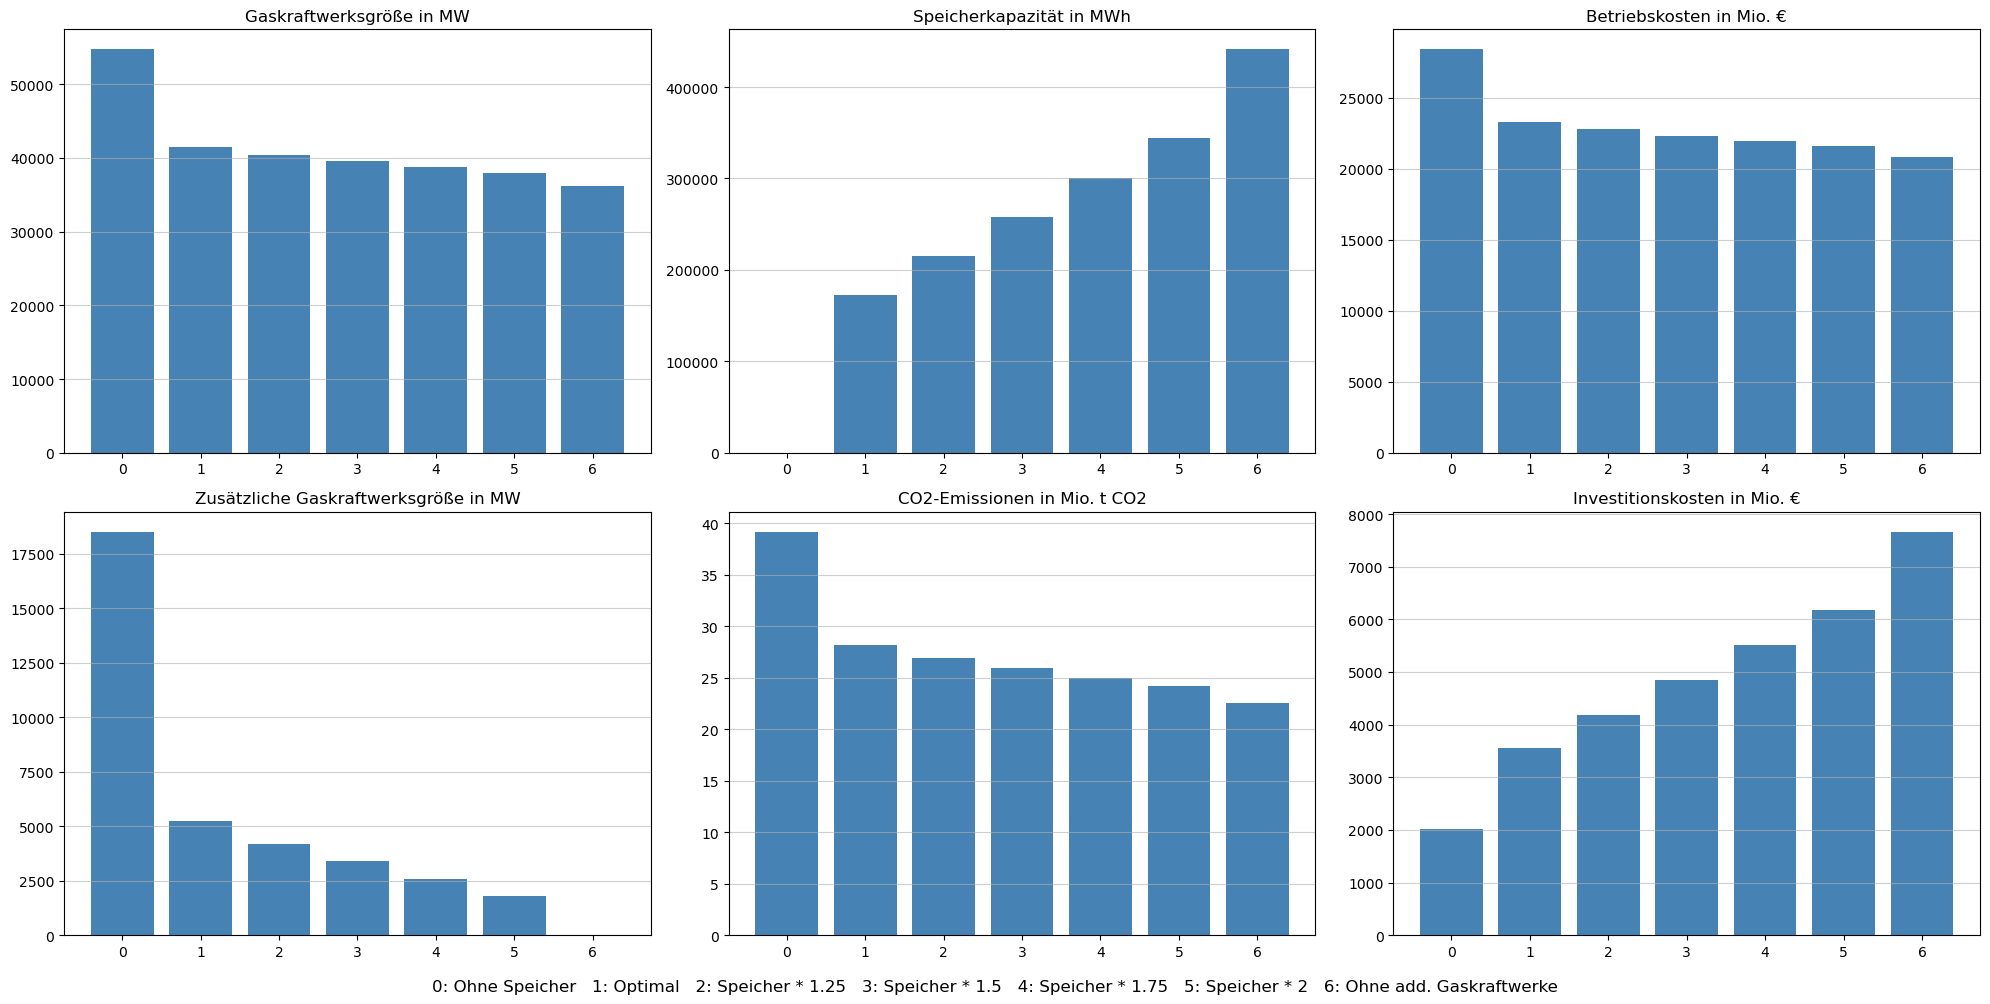

In [51]:
fig, axs = plt.subplots(2, 3, figsize=(20,10))

x_labels = df_results.columns.tolist()

color = 'steelblue'

for ax in axs.flat:
    ax.grid(axis = 'y', linestyle='-', alpha=0.6)

axs[0, 0].bar(range(len(x_labels)), df_results.loc['Installierte Gaskraftwerksleistung [MW]'], color = color)
axs[0, 0].set_title('Gaskraftwerksgröße in MW')
axs[1, 0].bar(range(len(x_labels)), df_results.loc['Installierte add. Gaskraftwerksleistung [MW]'], color = color)
axs[1, 0].set_title('Zusätzliche Gaskraftwerksgröße in MW')
axs[0, 1].bar(range(len(x_labels)), df_results.loc['Speicherkapazität in MWh'], color = color)
axs[0, 1].set_title('Speicherkapazität in MWh')
axs[1, 1].bar(range(len(x_labels)), df_results.loc['CO2-Emissionen in Mio. t CO2'], color = color)
axs[1, 1].set_title('CO2-Emissionen in Mio. t CO2')
axs[0, 2].bar(range(len(x_labels)), df_results.loc['Betriebskosten [Mio. €]'] , color = color)
axs[0, 2].set_title('Betriebskosten in Mio. €')
axs[1, 2].bar(range(len(x_labels)), df_results.loc['Investitionskosten [Mio. €]'] , color = color)
axs[1, 2].set_title('Investitionskosten in Mio. €')

legend_text = '   '.join([f"{i}: {x_labels[i]}" for i in range(len(x_labels))])
fig.text(0.5,0, legend_text, ha='center', va='bottom', fontsize=12)

fig.tight_layout(rect=[0, 0.02, 1, 1])